# Visualizando dados

Um item essencial do kit de ferramentas do cientista de dados é a visualização de dados. 
Embora seja muito fácil de criá-las, é bem difícil produzir boas visualizações.

In [69]:
# função para salvar as figuras:
from pathlib import Path

import matplotlib.pyplot as plt

# Onde salvar as figuras geradas neste notebook.
IMAGES_PATH = Path("images") / "fundamentals"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

### matplotlib

Primeiros gráficos com a biblioteca, usando linhas para relacionar anos e PIB.

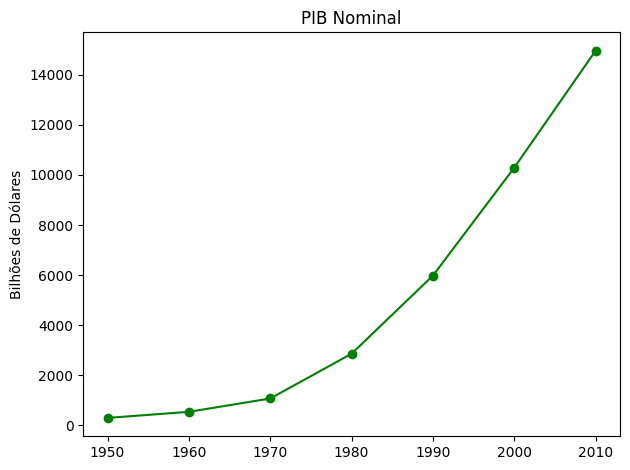

In [70]:
from matplotlib import pyplot as plt

years = [1950, 1960, 1970, 1980, 1990, 2000, 2010]
gdp = [300.2, 543.3, 1075.9, 2862.5, 5979.6, 10289.7, 14958.3]

# crie um grafico de linhas, anos no eixo x e gdp no eixo y
plt.plot(years, gdp, color='green', marker='o', linestyle='solid')

# adicione um titulo (original=Nominal GPD)
plt.title("PIB Nominal")

# adicione um rotulo ao eixo y (original=Billions of $)
plt.ylabel("Bilhões de Dólares")

save_fig('Figura 3-1. Um grafico de linhas simples')

plt.show()


### Gráficos de Barras

Comparando categorias e distribuições discretas por meio da altura das barras.

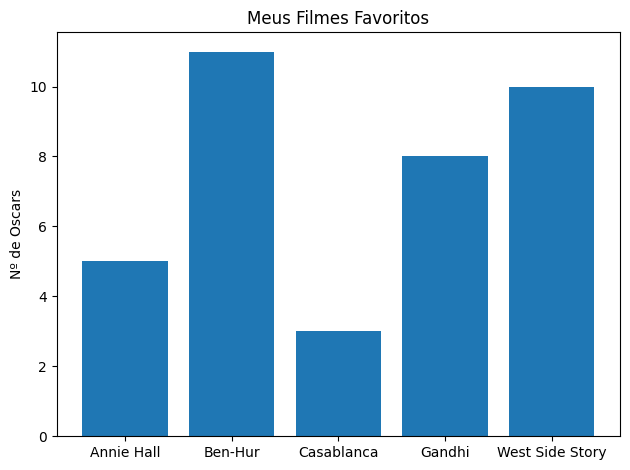

In [71]:
movies = ["Annie Hall", "Ben-Hur", "Casablanca", "Gandhi", "West Side Story"]
num_oscars = [5, 11, 3, 8, 10]

# plote as barras com coordenadas x a esquerda [0, 1, 2, 3, 4], alturas [num_oscars]
plt.bar(movies, num_oscars) # Pythonic

plt.title("Meus Filmes Favoritos")  # Adicione um titulo
plt.ylabel("Nº de Oscars")          # rotule o eixo y

# rotule o eixo x com os nomes dos filmes nos centros das barras
plt.xticks(movies)  # Pythonic

save_fig('Figura 3-2. Um grafico de barras simples')
plt.show()

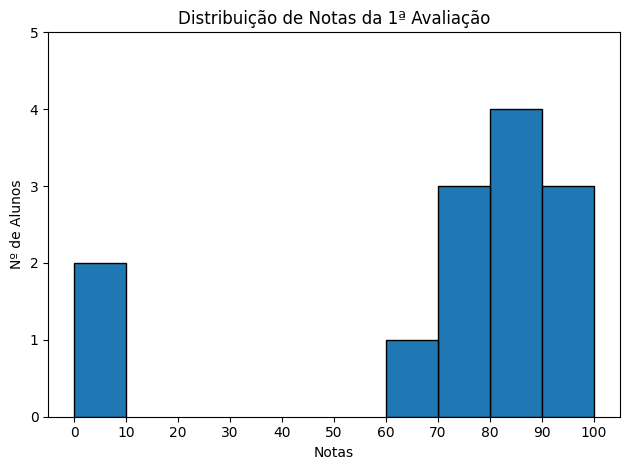

In [72]:
from collections import Counter 
grades = [83, 95, 91, 87, 70, 0, 85, 82, 100, 67, 73, 77, 0]

# Agrupe as notas por decil, mas coloque o 100 com o 90
histogram = Counter(min(grade // 10 * 10, 90) for grade in grades)

plt.bar([x + 5 for x in histogram.keys()],    # Mova a barra para a direita  em 5
        histogram.values(),                   # Atribua a altura correta a cada barra
        10,                                   # Atribua a largura 10 a cada barra 
        edgecolor=(0, 0, 0))                  # Escureca as bordas das barras 

plt.axis([-5, 105,  # eixo x de -5 a 105
          0, 5])    # eixo y de 0 a 5           

plt.xticks([10 * i for i in range(11)])         # os rotulos do eixo x em 0, 10, ..., 100   
plt.xlabel("Notas")
plt.ylabel("Nº de Alunos")
plt.title("Distribuição de Notas da 1ª Avaliação")

save_fig('Figura 3-3. Criando um histograma com um grafico de barras')
plt.show()

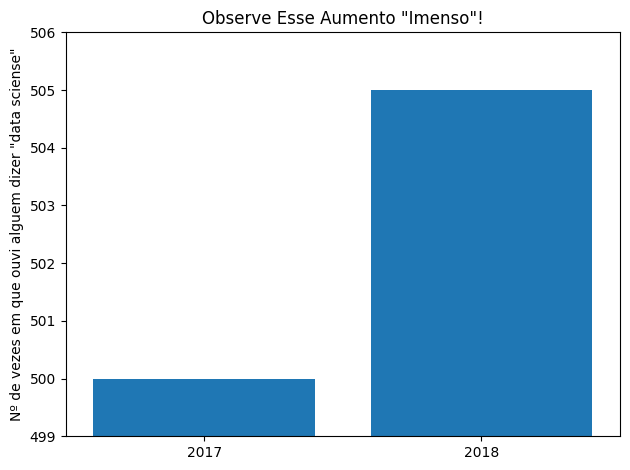

In [73]:
metions = [500, 505]
years = [2017, 2018]

plt.bar(years, metions, 0.8)
plt.xticks(years)
plt.ylabel('Nº de vezes em que ouvi alguem dizer "data sciense"')

# se voce nao fizer isso, matplotlib rotulara o eixo x como 0, 1 e adicionara um +2.013e3 off no canto (que feio, matplotlib!)
# plt.ticklabel_format(userOffset=False)

# o eixo y malandro mostra apenas a parte acima de 500
plt.axis([2016.5, 2018.5, 499, 506])
plt.title('Observe Esse Aumento "Imenso"!')

save_fig('Figura 3-4. Um grafico com um eixo y malandro')
plt.show()

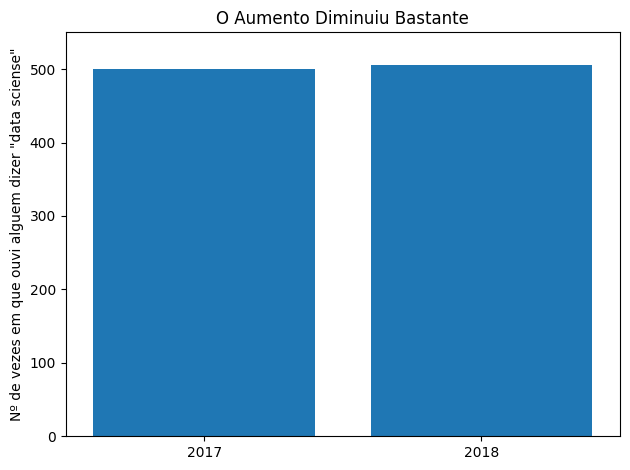

In [74]:
metions = [500, 505]
years = [2017, 2018]

plt.bar(years, metions, 0.8)
plt.xticks(years)
plt.ylabel('Nº de vezes em que ouvi alguem dizer "data sciense"')

plt.axis([2016.5, 2018.5, 0, 550])
plt.title('O Aumento Diminuiu Bastante')

save_fig('Figura 3-5. O mesmo grafico com um eixo y boa-praca')
plt.show()

### Gráficos de Linhas

Acompanhando séries e comparando múltiplas curvas no mesmo conjunto de eixos.

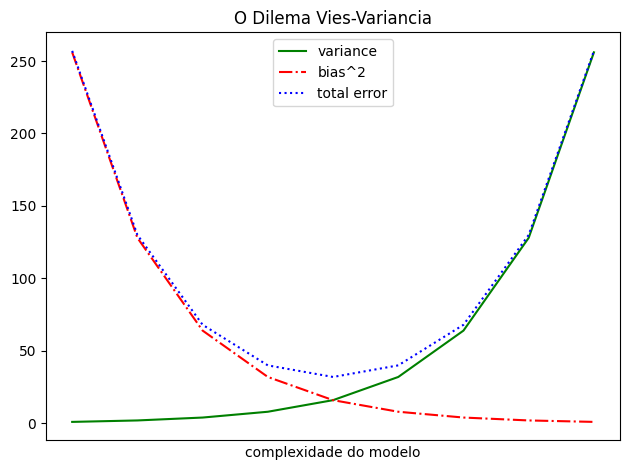

In [75]:
variance = [1, 2, 4, 8, 16, 32, 64, 128, 256]
bias_squared = [256, 128, 64, 32, 16, 8, 4, 2, 1]
total_error = [x + y for x, y in zip(variance, bias_squared)]
xs = [i for i, _ in enumerate(variance)]

# Podemos fazer multiplas chamadas para plt.plot
# Para mostrar multiplas series no mesmo grafico
plt.plot(xs, variance,     'g-', label='variance')   # Linha verde solida
plt.plot(xs, bias_squared, 'r-.', label='bias^2')    # Linha vermelha de ponto tracejado

plt.plot(xs, total_error, 'b:', label='total error') # Linha pontilhada azul

# Como atribuimos rotulos a cada serie, podemos criar uma legenda de graca (loc=9 menas "top center")
plt.legend(loc=9)
plt.xlabel("complexidade do modelo")
plt.xticks([])
plt.title("O Dilema Vies-Variancia")

save_fig("Figura 3-6. Varios graficos de linhas com uma legenda")
plt.show()

### Gráficos de Dispersão

Visualizando relações entre duas variáveis e observando como a escala dos eixos afeta a interpretação.

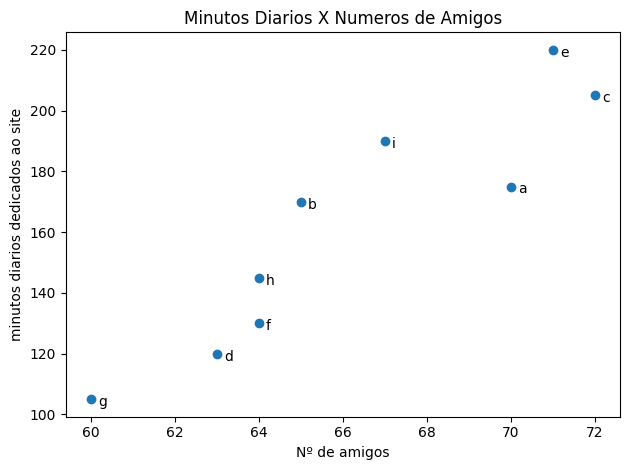

In [76]:
friends = [ 70,  65,  72,  63,  71,  64,  60,  64,  67]
minutes = [175, 170, 205, 120, 220, 130, 105, 145, 190]
labels  = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

plt.scatter(friends, minutes)

# rotula cada ponto
for label, friend_count, minute_count in zip(labels, friends, minutes):
    plt.annotate(label,
                 xy=(friend_count, minute_count),
                 xytext=(5, -5), # Coloque o rotulo no respectivo ponto mas levemente deslocado
                 textcoords='offset points')
    
plt.title("Minutos Diarios X Numeros de Amigos")
plt.xlabel("Nº de amigos")
plt.ylabel("minutos diarios dedicados ao site")

save_fig("Figura 3-7. Um grafico de dispersao entre o numero de amigos e o tempo dedicado ao site")

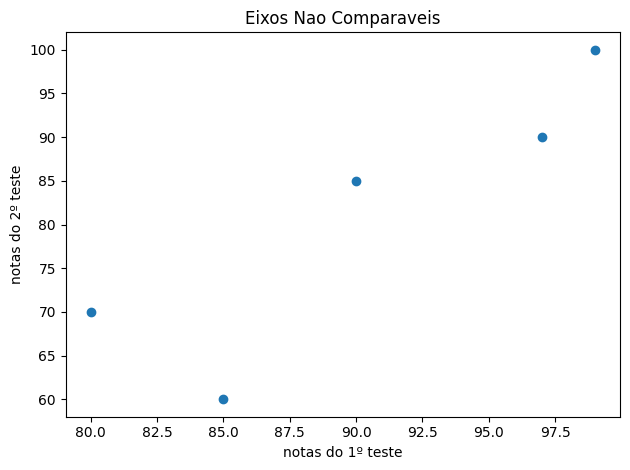

In [77]:
test_1_grades = [99, 90, 85, 97, 80]
test_2_grades = [100, 85, 60, 90, 70]

plt.scatter(test_1_grades, test_2_grades)
plt.title("Eixos Nao Comparaveis")
plt.xlabel("notas do 1º teste")
plt.ylabel("notas do 2º teste")

save_fig("Figura 3-8. Um grafico de dispersao com eixos imcomparaveis")
plt.show()

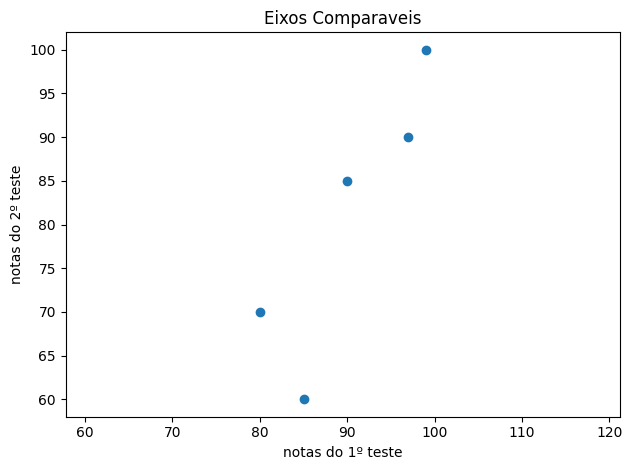

In [78]:
test_1_grades = [99, 90, 85, 97, 80]
test_2_grades = [100, 85, 60, 90, 70]

plt.scatter(test_1_grades, test_2_grades)
plt.title("Eixos Comparaveis")
plt.xlabel("notas do 1º teste")
plt.ylabel("notas do 2º teste")
plt.axis("equal")

save_fig("Figura 3-9. O mesmo grafico de dispersao com eixos iguais")
plt.show()